In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from hmmlearn import hmm

df = pd.read_csv("raw_tracking_data.csv")

# Keep only high-precision GPS fixes, if a sensor-type column is present
if "sensor-type" in df.columns:
    df = df[df["sensor-type"] == "gps"]

df = df.rename(columns={
    "location-lat": "lat",
    "location-long": "lon",
    "timestamp": "timestamp",
    "individual-local-identifier": "animal_id"
})
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df[["animal_id", "timestamp", "lat", "lon"]].dropna()
df = df.sort_values(["animal_id", "timestamp"]).reset_index(drop=True)
df.head()


,animal_id,timestamp,lat,lon
0,45101,2014-07-10,28.054000,-90.905000
1,45101,2014-07-11,26.707780,-91.150922
2,45101,2014-07-12,26.693058,-91.194314
3,45101,2014-07-13,26.718662,-91.434551
4,45101,2014-07-14,26.878502,-91.667210


In [2]:
print(df["animal_id"].value_counts())

chosen_id = 128786  # no quotes — animal_id is int64
track = df[df["animal_id"] == chosen_id].reset_index(drop=True)
print(f"Using shark {chosen_id}, {len(track)} points")


animal_id
128786    367
128783    366
128784    349
128781    249
101197    243
85238     209
128779    184
100512    151
85224     130
100516    121
45101     100
128787     99
100508     97
102303     82
100510     71
85237      70
77007      52
101198     46
101199     44
128782     38
128778     29
100519     28
128386     27
128780     27
100521     21
128382     21
100522     19
85226      11
85225       9
100523      9
100526      9
128383      9
128385      8
132396      7
100518      6
102308      6
100490      5
132393      5
100489      4
100517      3
85227       2
Name: count, dtype: int64
Using shark 128786, 367 points


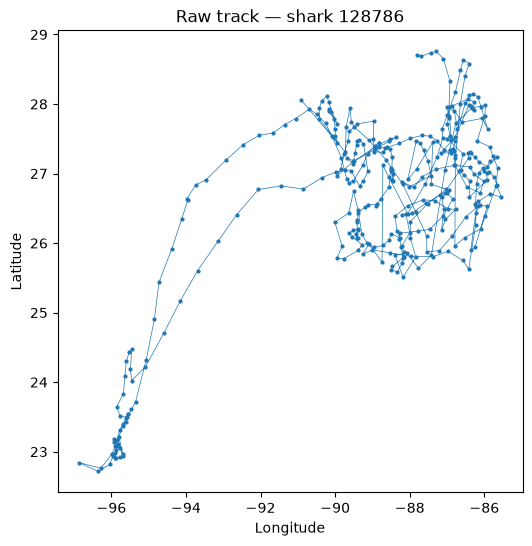

In [3]:
plt.figure(figsize=(6,6))
plt.plot(track["lon"], track["lat"], marker="o", markersize=2, linewidth=0.5)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"Raw track — shark {chosen_id}")
plt.show()

In [4]:
gaps = track["timestamp"].diff().dt.total_seconds() / 3600
print(gaps.describe())

count    366.0
mean      24.0
std        0.0
min       24.0
25%       24.0
50%       24.0
75%       24.0
max       24.0
Name: timestamp, dtype: float64


In [5]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

track["step_length_km"] = haversine_km(
    track["lat"], track["lon"],
    track["lat"].shift(-1), track["lon"].shift(-1)
)
print(track["step_length_km"].describe())

count    366.000000
mean      29.264226
std       21.435848
min        0.829372
25%       13.977100
50%       23.877587
75%       39.943955
max      154.839639
Name: step_length_km, dtype: float64


In [6]:
def bearing(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlon = lon2 - lon1
    x = np.sin(dlon) * np.cos(lat2)
    y = np.cos(lat1)*np.sin(lat2) - np.sin(lat1)*np.cos(lat2)*np.cos(dlon)
    return np.arctan2(x, y)

track["bearing"] = bearing(track["lat"], track["lon"],
    track["lat"].shift(-1), track["lon"].shift(-1))
track["turn_angle_rad"] = track["bearing"].diff()
track["turn_angle_rad"] = (track["turn_angle_rad"] + np.pi) % (2*np.pi) - np.pi

In [7]:
track = track.dropna(subset=["step_length_km", "turn_angle_rad"]).reset_index(drop=True)
print(track[["step_length_km", "turn_angle_rad"]].describe())

       step_length_km  turn_angle_rad
count      365.000000      365.000000
mean        29.024728       -0.130538
std         20.969188        1.194806
min          0.829372       -3.134624
25%         13.966217       -0.676542
50%         23.793710       -0.078212
75%         39.794046        0.439686
max        154.839639        3.010898


In [8]:
X = track[["step_length_km", "turn_angle_rad"]].values
model = hmm.GaussianHMM(n_components=2, covariance_type="diag",
                         n_iter=200, random_state=42)
model.fit(X)
track["state"] = model.predict(X)
print(track["state"].value_counts())

state
1    197
0    168
Name: count, dtype: int64


In [9]:
means = track.groupby("state")["step_length_km"].mean()
travel_state = means.idxmax()
track["behavior"] = track["state"].apply(
    lambda s: "Traveling" if s == travel_state else "Foraging"
)
print(track["behavior"].value_counts(normalize=True) * 100)

behavior
Foraging     53.972603
Traveling    46.027397
Name: proportion, dtype: float64


In [10]:
track.groupby("behavior")["step_length_km"].describe()

,count,mean,std,min,25%,50%,75%,max
behavior,,,,,,,,
Foraging,197.0,15.58888,7.536661,0.829372,10.241111,14.943616,20.540627,35.793522
Traveling,168.0,44.77986,20.714157,3.270298,32.055917,40.986131,54.281514,154.839639


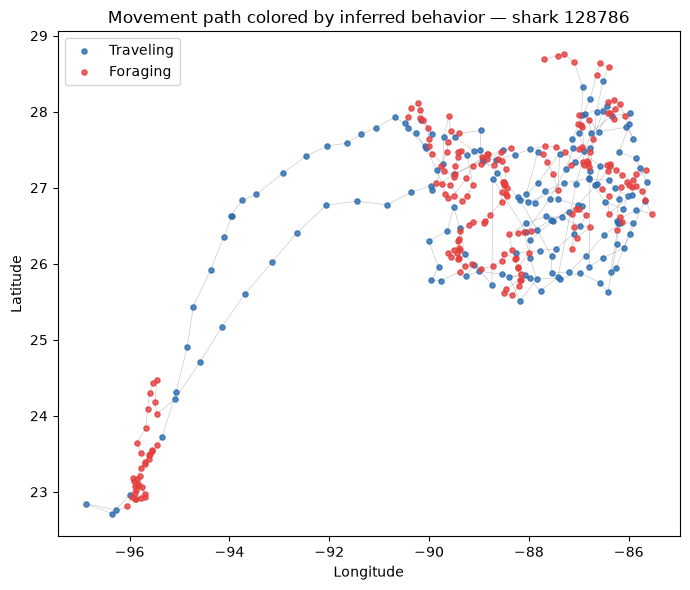

In [11]:
colors = {"Traveling": "#2b6cb0", "Foraging": "#e53e3e"}
plt.figure(figsize=(7,6))
for b, c in colors.items():
    sub = track[track["behavior"] == b]
    plt.scatter(sub["lon"], sub["lat"], s=14, color=c, label=b, alpha=0.8)
plt.plot(track["lon"], track["lat"], color="gray", linewidth=0.4, alpha=0.5, zorder=0)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"Movement path colored by inferred behavior — shark {chosen_id}")
plt.legend()
plt.tight_layout()
plt.savefig("fig1_track_by_state.png", dpi=150)
plt.show()

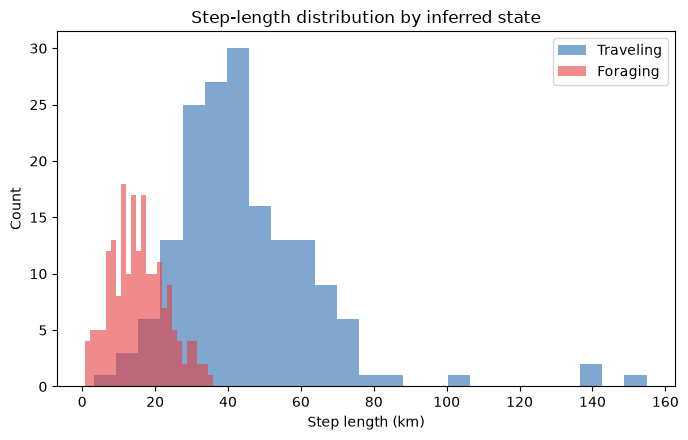

In [12]:
plt.figure(figsize=(7,4.5))
for b, c in colors.items():
    sub = track[track["behavior"] == b]
    plt.hist(sub["step_length_km"], bins=25, alpha=0.6, color=c, label=b)
plt.xlabel("Step length (km)")
plt.ylabel("Count")
plt.title("Step-length distribution by inferred state")
plt.legend()
plt.tight_layout()
plt.savefig("fig2_step_length_hist.png", dpi=150)
plt.show()

In [13]:
track.to_csv("tracking_data_with_states.csv", index=False)